Same code as data explorations but with data set from the last 300 tournamens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/Users/tliu/Desktop/Erdos Project/3_Player_Data_Generation/match_data_300_tourns_modified.csv')

In [3]:
data.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id,date
0,Mark Allen,Ricky Walden,7,1580,1418,0.709992,0.599888,501,313,3345,...,45,25,1032,557,0,4,1.0,0.000000,1063,1.415318e+18
1,Stephen Maguire,Judd Trump,7,1563,1551,0.516401,0.507499,663,444,4995,...,122,79,1344,782,1,4,1.0,0.200000,1063,1.415059e+18
2,Mark Selby,Steve Davis,7,1592,1246,0.878716,0.703704,736,495,5330,...,8,2,581,286,4,1,0.0,0.800000,1063,1.415059e+18
3,Neil Robertson,Ali Carter,7,1546,1544,0.502734,0.501250,621,402,4581,...,11,5,876,499,4,0,0.0,1.000000,1063,1.415318e+18
4,Stuart Bingham,Ronnie O'Sullivan,7,1488,1663,0.275106,0.392337,744,462,5592,...,71,46,674,431,2,4,1.0,0.333333,1063,1.415146e+18


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34521 entries, 0 to 34520
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   34521 non-null  object 
 1   player2                   34521 non-null  object 
 2   best_of                   34521 non-null  int64  
 3   player1_elo               34521 non-null  int64  
 4   player2_elo               34521 non-null  int64  
 5   elo_match_win_rate        34521 non-null  float64
 6   elo_frame_win_rate        34521 non-null  float64
 7   p1_matches_played         34521 non-null  int64  
 8   p1_matches_won            34521 non-null  int64  
 9   p1_frames_played          34521 non-null  int64  
 10  p1_frames_won             34521 non-null  int64  
 11  p2_matches_played         34521 non-null  int64  
 12  p2_matches_won            34521 non-null  int64  
 13  p2_frames_played          34521 non-null  int64  
 14  p2_fra

In [5]:
data.columns

Index(['player1', 'player2', 'best_of', 'player1_elo', 'player2_elo',
       'elo_match_win_rate', 'elo_frame_win_rate', 'p1_matches_played',
       'p1_matches_won', 'p1_frames_played', 'p1_frames_won',
       'p2_matches_played', 'p2_matches_won', 'p2_frames_played',
       'p2_frames_won', 'p1_frames_played_1_year', 'p1_frames_won_1_year',
       'p1_frames_played_3_years', 'p1_frames_won_3_years',
       'p2_frames_played_1_year', 'p2_frames_won_1_year',
       'p2_frames_played_3_years', 'p2_frames_won_3_years', 'score1', 'score2',
       'match_result', 'win_percentage', 'tournament_id', 'date'],
      dtype='object')

***

## 1. Explore the prediction accurary by elo on different range of matches.

We plot the rolling average of correct prediction (i.e. prediction accuracy on certain range of matches). This is inspired by much lower prediction accuracy on the test set than on the training set during our first attempt of modeling. 

In [6]:
prediction = data['player1_elo'] < data['player2_elo']
correct_pred = (prediction == data['match_result'])

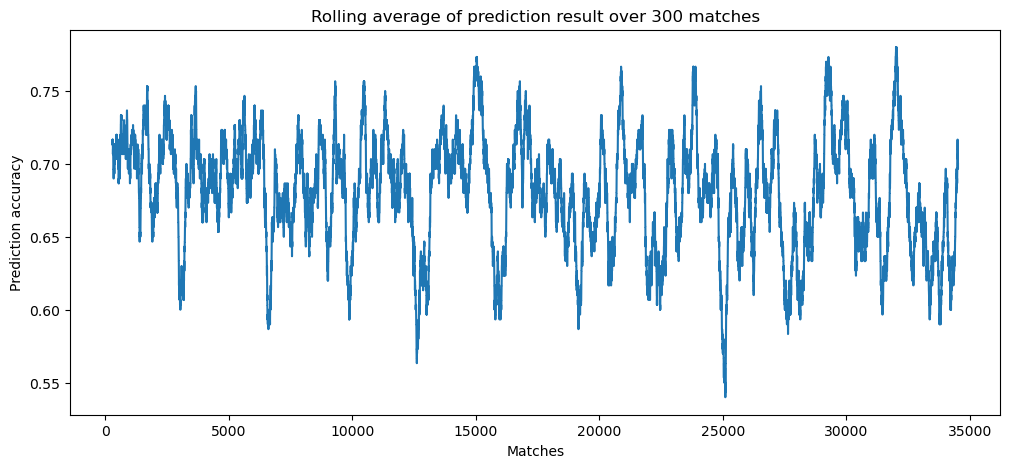

In [7]:
rolling_300 = correct_pred.rolling(window=300).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_300)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 300 matches')
plt.show()

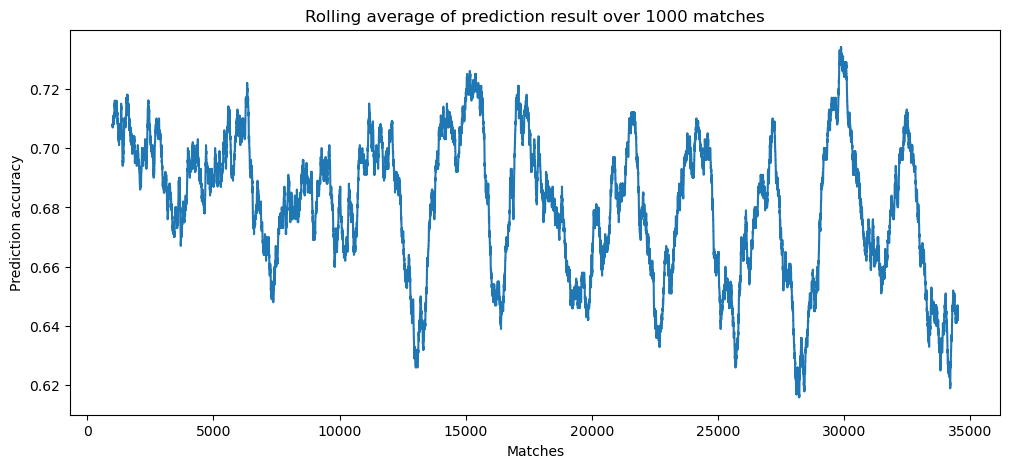

In [8]:
rolling_1k = correct_pred.rolling(window=1000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_1k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 1000 matches')
plt.show()

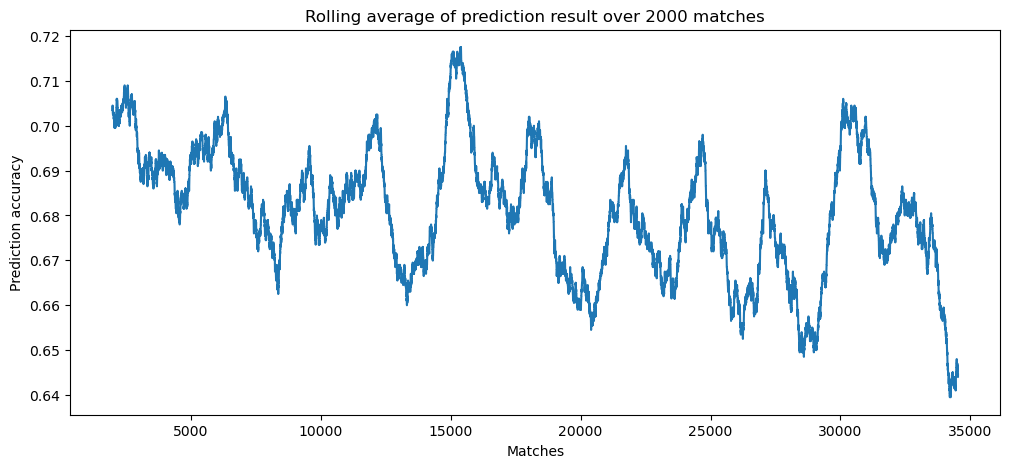

In [9]:
rolling_2k = correct_pred.rolling(window=2000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_2k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 2000 matches')
plt.show()

From the two graphs, we see that the performance of prediction by our elo rating system fluntuates and drops significantly in the last 1000-2000 matches. We will try to investigate the reason below.

### Plot some stats of players

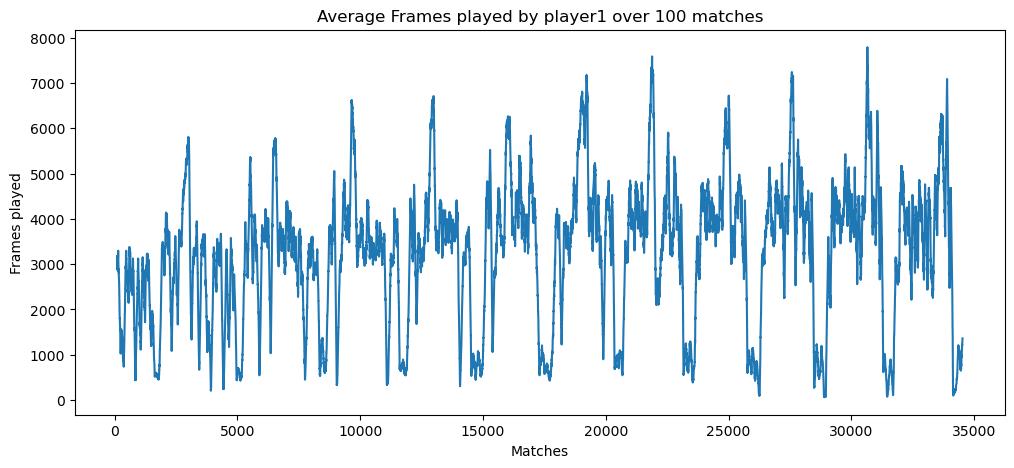

In [10]:
rolling1 = data['p1_frames_played'].rolling(window=100).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling1)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player1 over 100 matches')
plt.show()

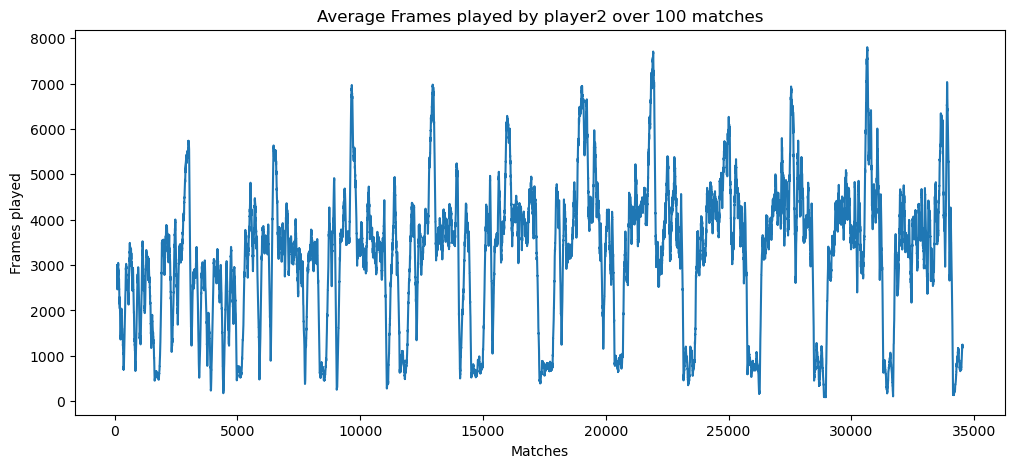

In [11]:
rolling2 = data['p2_frames_played'].rolling(window=100).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player2 over 100 matches')
plt.show()

Two graphs indicate that the average number of frames played by players is significantly lower at some time. One reason for this trend can be that there are lots of matches that are not at the highest level are recorded and the players are not as experienced as the top players and don't have much professional matches record. For example, Pubo pointed out that Q school is a series of tournaments among amateurs happening in the early seaon every year which serves as qualification school for world snooker tour. These tournaments are among amateur players but still marked as professional level by our data source cuetracker.net.  

Let's us drop the these matches and see what can happen.

In [12]:
tournaments = pd.read_csv('/Users/tliu/Desktop/Erdos Project/1_Match_Data/Kaggle Data/Raw Data/tournaments.csv')
# Get the Q school tournaments id before 2020
Q_school_tournament_ids = []
for i in range(len(tournaments)):
    tourn = tournaments.iloc[i]
    if 'Q School' in tourn['name']:
        Q_school_tournament_ids.append(tourn['id'])

# Manually add Q_school tournament ids between 2020 and 2025.
Q_school_tournament_ids += [6802, 6803, 6785, 6786,
                           6140, 6180, 6142, 6183,
                           5674, 5675, 5700, 5701,
                           4922, 4923, 4924, 4959, 4960,
                           4405, 4409, 4410,
                           3752, 3753, 3754
                           ]
len(Q_school_tournament_ids)

46

In [13]:
#drop Q school matches. 

for id in Q_school_tournament_ids: 
    matches_indices = data[data['tournament_id'] == id].index
    print(f'Deleting {len(data[data['tournament_id'] == id])} rows.')
    data.drop(matches_indices, axis = 0, inplace = True)

data.reset_index(inplace = True, drop = True)


Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 0 rows.
Deleting 133 rows.
Deleting 138 rows.
Deleting 153 rows.
Deleting 158 rows.
Deleting 170 rows.
Deleting 178 rows.
Deleting 196 rows.
Deleting 200 rows.
Deleting 178 rows.
Deleting 190 rows.
Deleting 194 rows.
Deleting 203 rows.
Deleting 209 rows.
Deleting 213 rows.
Deleting 163 rows.
Deleting 159 rows.
Deleting 83 rows.
Deleting 81 rows.
Deleting 160 rows.
Deleting 153 rows.
Deleting 95 rows.
Deleting 93 rows.
Deleting 202 rows.
Deleting 198 rows.
Deleting 90 rows.
Deleting 88 rows.
Deleting 161 rows.
Deleting 158 rows.
Deleting 154 rows.
Deleting 65 rows.
Deleting 63 rows.
Deleting 188 rows.
Deleting 186 rows.
Deleting 181 rows.
Deleting 151 rows.
Deleting 146 rows.
Deleting 143 rows.


In [14]:
data

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id,date
0,Mark Allen,Ricky Walden,7,1580,1418,0.709992,0.599888,501,313,3345,...,45,25,1032,557,0,4,1.0,0.000000,1063,1.415318e+18
1,Stephen Maguire,Judd Trump,7,1563,1551,0.516401,0.507499,663,444,4995,...,122,79,1344,782,1,4,1.0,0.200000,1063,1.415059e+18
2,Mark Selby,Steve Davis,7,1592,1246,0.878716,0.703704,736,495,5330,...,8,2,581,286,4,1,0.0,0.800000,1063,1.415059e+18
3,Neil Robertson,Ali Carter,7,1546,1544,0.502734,0.501250,621,402,4581,...,11,5,876,499,4,0,0.0,1.000000,1063,1.415318e+18
4,Stuart Bingham,Ronnie O'Sullivan,7,1488,1663,0.275106,0.392337,744,462,5592,...,71,46,674,431,2,4,1.0,0.333333,1063,1.415146e+18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28842,Luca Brecel,Judd Trump,25,1459,1639,0.128899,0.389361,673,392,4518,...,235,141,1554,970,8,13,1.0,0.380952,6743,1.745885e+18
28843,Ronnie O'Sullivan,Si Jiahui,25,1534,1409,0.784511,0.577495,1551,1178,13371,...,126,56,940,508,13,9,0.0,0.590909,6743,1.745885e+18
28844,Ronnie O'Sullivan,Zhao Xintong,33,1534,1504,0.585909,0.518741,1551,1178,13371,...,0,0,58,39,7,17,1.0,0.291667,6743,1.746058e+18
28845,Judd Trump,Mark Williams,33,1639,1497,0.847260,0.587830,1530,1103,10578,...,72,29,879,499,14,17,1.0,0.451613,6743,1.746058e+18


Run the rolling average of correct prediction again. 

In [15]:
new_prediction = data['player1_elo'] < data['player2_elo']
new_correct_pred = (new_prediction == data['match_result'])

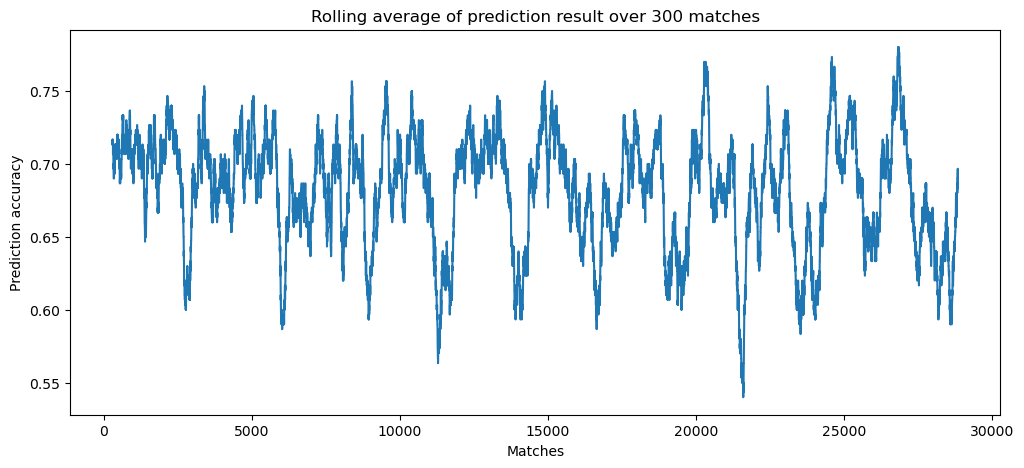

In [16]:
rolling2_300 = new_correct_pred.rolling(window=300).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2_300)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 300 matches')
plt.show()

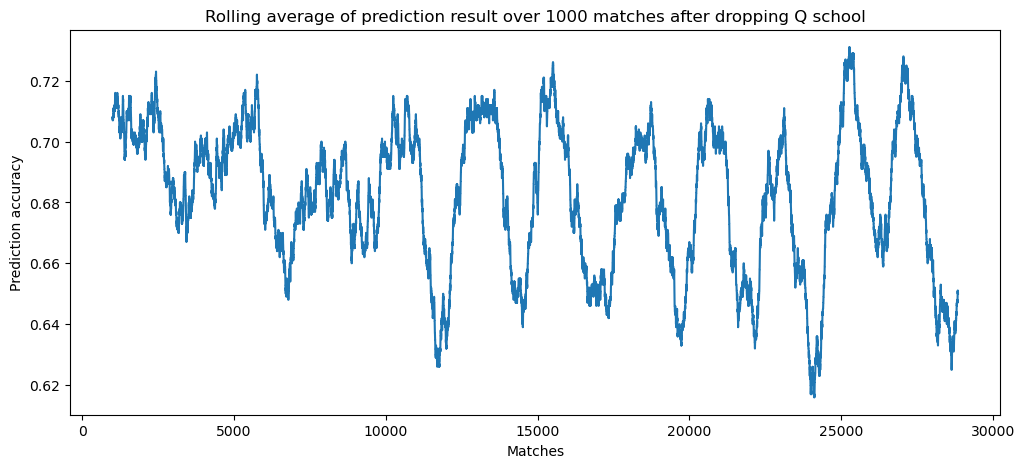

In [17]:
rolling2_1k = new_correct_pred.rolling(window=1000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2_1k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 1000 matches after dropping Q school')
plt.show()

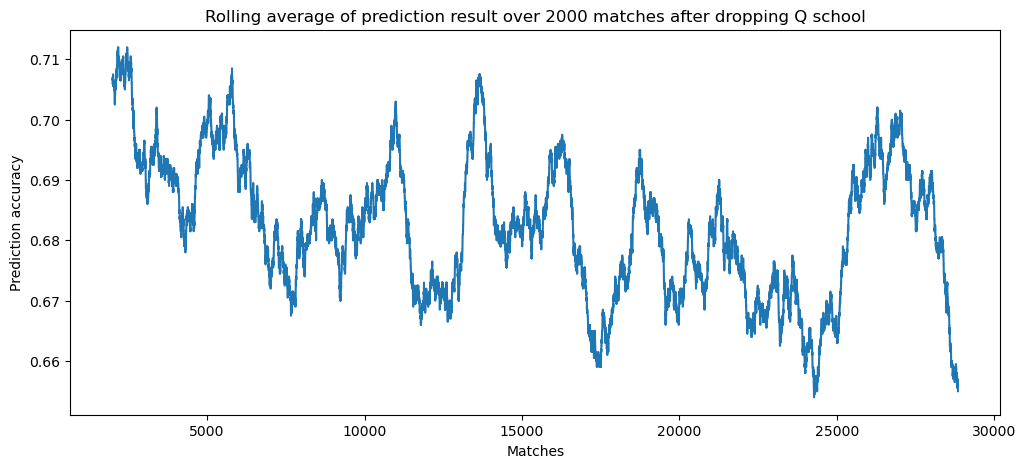

In [18]:
rolling2_2k = new_correct_pred.rolling(window=2000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2_2k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 2000 matches after dropping Q school')
plt.show()

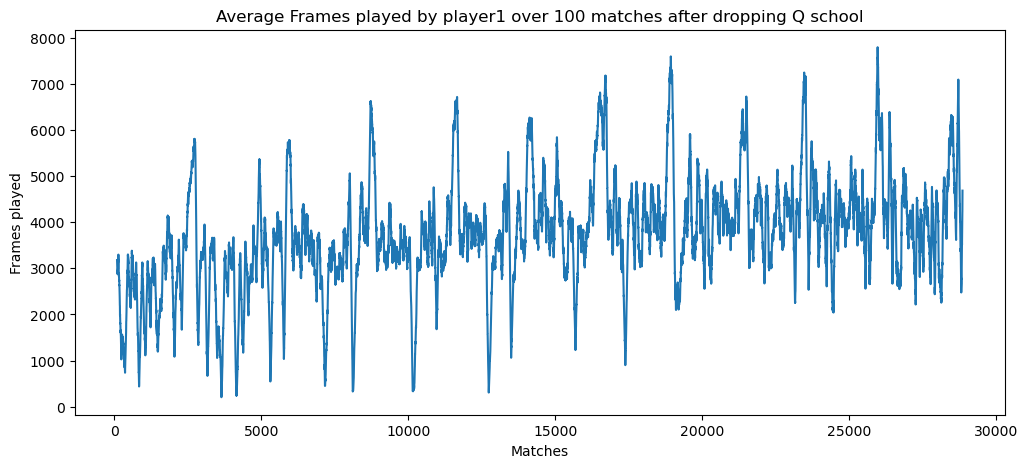

In [19]:
rolling2_1 = data['p1_frames_played'].rolling(window=100).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2_1)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player1 over 100 matches after dropping Q school')
plt.show()

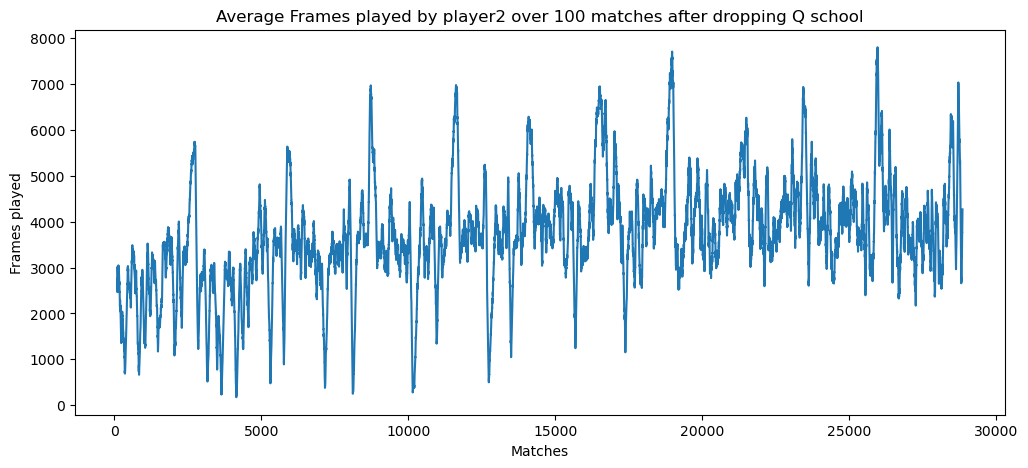

In [20]:
rolling2_2 = data['p2_frames_played'].rolling(window=100).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling2_2)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player2 over 100 matches after dropping Q school')
plt.show()

We see that after dropping the Q school matches, lots of matches with low average frames played were exluded. However, the average prediction accuracy is still not consistent.

### 1.5 Prediction accuracy by tournaments

***

In [21]:
data = pd.read_csv('/Users/tliu/Desktop/Erdos Project/3_Player_Data_Generation/match_data_300_tourns_modified.csv')

In [22]:
accuracy_by_tourn = []
Q_school_accuracy = []
num_of_matches = []
tournaments = data['tournament_id'].unique()
for tournament in tournaments:
    
    matches = data[data['tournament_id'] == tournament]
    tourn_prediction = matches['player1_elo'] < matches['player2_elo']
    tourn_correct_pred = (tourn_prediction == matches['match_result'])
    accuracy = tourn_correct_pred.sum()/len(tourn_correct_pred)
    accuracy_by_tourn.append(accuracy)
    num_of_matches.append(len(matches))
    if tournament in Q_school_tournament_ids:
        Q_school_accuracy.append(accuracy)

In [25]:
# Print the numbers of matches in the tournaments: top 10 and bottom 10
num_of_matches.sort()
print(num_of_matches[:10])
print(num_of_matches[-10:])

[6, 7, 7, 7, 7, 7, 7, 7, 9, 11]
[225, 233, 238, 251, 253, 253, 253, 253, 276, 588]


Some tournaments have very few matches. That might make the accuracy within these tournaments very inconsistent.

In [23]:
print(f'The average accuracy overall is {sum(accuracy_by_tourn)/len(accuracy_by_tourn)}.')
print(f'The average accuracy for Q school tournaments is {sum(Q_school_accuracy)/len(Q_school_accuracy)}.')

The average accuracy overall is 0.6705392830188045.
The average accuracy for Q school tournaments is 0.6642782443735691.


We see that the average prediction accuracy for Q school tournaments is slightly lower than overall accuracy. However, the difference is not big.

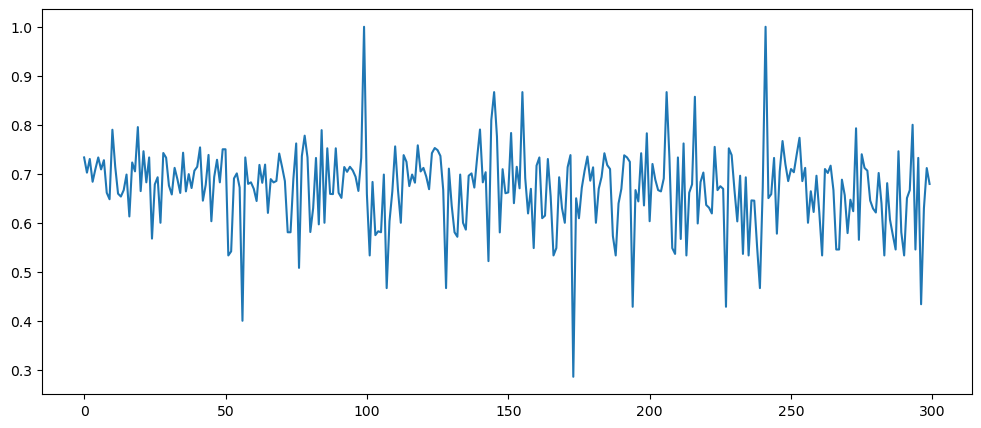

In [24]:
# Plot the accuracy of elo prediction for each tournament.
plt.figure(figsize=(12,5))
plt.plot(accuracy_by_tourn)
plt.show()

***

## 2. Plot and interpret distributions of players' stats

In [25]:
data = pd.read_csv('/Users/tliu/Desktop/Erdos Project/3_Player_Data_Generation/match_data_300_tourns_modified.csv')

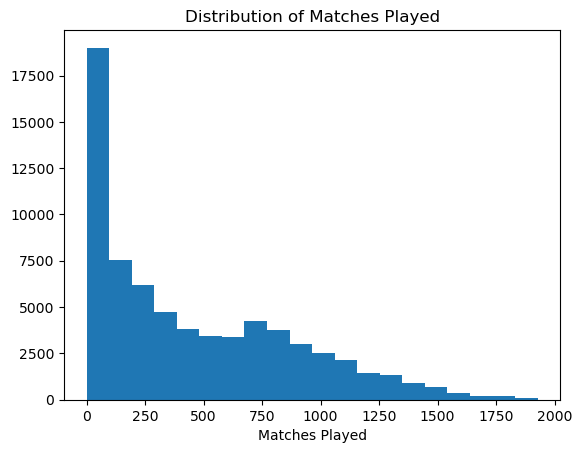

In [26]:
matches_played = pd.concat([data['p1_matches_played'], data['p1_matches_played']], axis = 0)
plt.hist(matches_played.values, bins = 20)
plt.xlabel('Matches Played')
plt.title('Distribution of Matches Played')
plt.show()

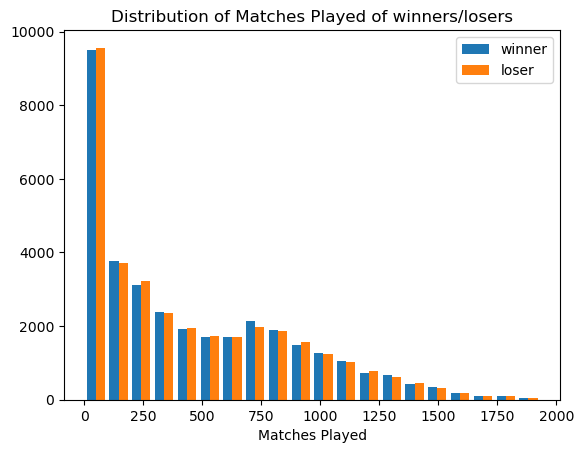

In [27]:
matches_played = pd.concat([data['p1_matches_played'], data['p2_matches_played']], axis = 1)
plt.hist(matches_played.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Matches Played')
plt.title('Distribution of Matches Played of winners/losers')
plt.legend()
plt.show()

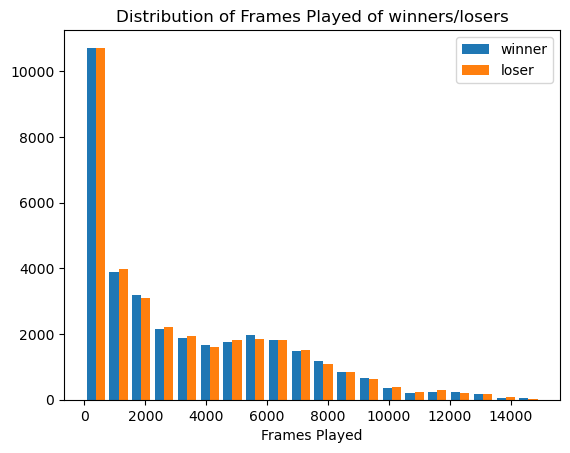

In [28]:
frames_played = pd.concat([data['p1_frames_played'], data['p2_frames_played']], axis = 1)
plt.hist(frames_played.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played')
plt.title('Distribution of Frames Played of winners/losers')
plt.legend()
plt.show()

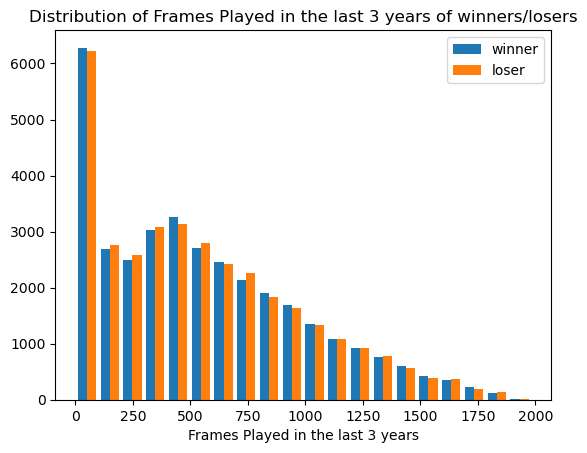

In [29]:
frames_played_3_years = pd.concat([data['p1_frames_played_3_years'], data['p2_frames_played_3_years']], axis = 1)
plt.hist(frames_played_3_years.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played in the last 3 years')
plt.title('Distribution of Frames Played in the last 3 years of winners/losers')
plt.legend()
plt.show()

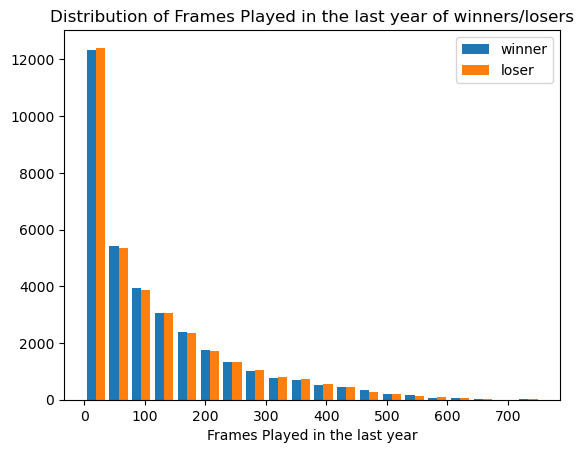

In [30]:
frames_played_1_year = pd.concat([data['p1_frames_played_1_year'], data['p2_frames_played_1_year']], axis = 1)
plt.hist(frames_played_1_year.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played in the last year')
plt.title('Distribution of Frames Played in the last year of winners/losers')
plt.legend()
plt.show()

We can see that there are lots of players with low or even zero matches and frames played. For these players, their matches are going to be very hard to predict because they haven't played enough game to establish their elo rating. Also, in the last four hisotgrams, the left most orange bar is obviously taller than the blue bar, indicating that the professional players who don't have much matches record tend to be the loser.

***

## 3. Plot and interpret the distribution of elo ratings.

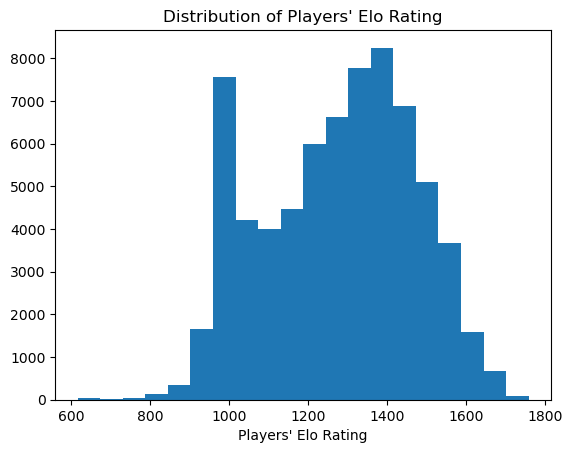

In [31]:
elo = pd.concat([data['player1_elo'], data['player2_elo']], axis = 0)
plt.hist(elo.values, bins = 20)
plt.xlabel('Players\' Elo Rating')
plt.title('Distribution of Players\' Elo Rating')
plt.show()


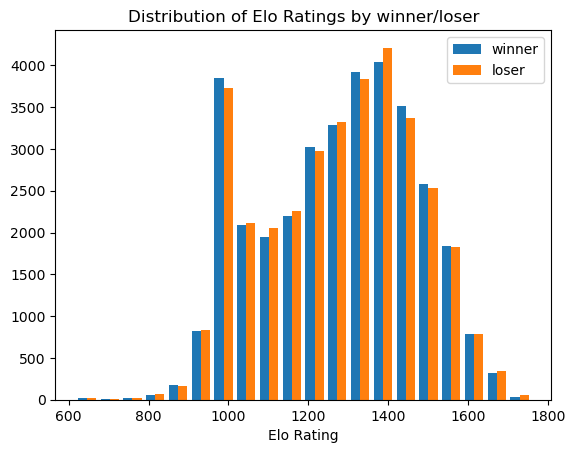

In [32]:
elo2 = pd.concat([data['player1_elo'], data['player2_elo']], axis = 1)
plt.hist(elo2.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Elo Rating')
plt.title('Distribution of Elo Ratings by winner/loser')
plt.legend()
plt.show()

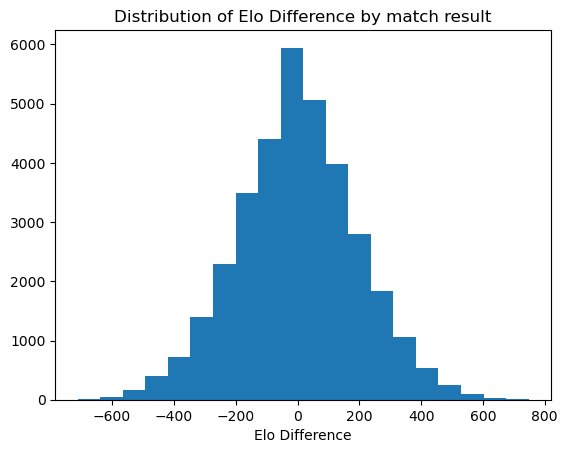

In [33]:
#Matches elo difference by result. Notice that in this data frame, player1 is always the winner. 
elo_diff = data['player1_elo'] - data['player2_elo']
plt.hist(elo_diff, bins = 20,)
plt.xlabel('Elo Difference')
plt.title('Distribution of Elo Difference by match result')
plt.show()


In [34]:
elo_diff.describe()

count    34521.000000
mean         0.670027
std        194.011639
min       -711.000000
25%       -126.000000
50%          0.000000
75%        125.000000
max        748.000000
dtype: float64

According to the histogram 'Distribution of Elo Difference by match result', the slight asymmetry betwen -200 and 200 indicates that our elo rating system is likely to predict the match result with accuracy nontrivially higher than 50%.

***

## 4. Explore the correlations between the columns

In this section, we will use modified version of the above data, where player1 and player2 are swapped for half of the matches, so that player1 will not always be the winner.

In [35]:
#Add more features: matches_win_rate, frames_win_rate
data['p1_frames_win_rate'] = data['p1_frames_won']/ data['p1_frames_played']
data['p2_frames_win_rate'] = data['p2_frames_won']/ data['p2_frames_played']

data['p1_matches_win_rate'] = data['p1_matches_won']/ data['p1_matches_played']
data['p2_matches_win_rate'] = data['p2_matches_won']/ data['p2_matches_played']

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34521 entries, 0 to 34520
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   34521 non-null  object 
 1   player2                   34521 non-null  object 
 2   best_of                   34521 non-null  int64  
 3   player1_elo               34521 non-null  int64  
 4   player2_elo               34521 non-null  int64  
 5   elo_match_win_rate        34521 non-null  float64
 6   elo_frame_win_rate        34521 non-null  float64
 7   p1_matches_played         34521 non-null  int64  
 8   p1_matches_won            34521 non-null  int64  
 9   p1_frames_played          34521 non-null  int64  
 10  p1_frames_won             34521 non-null  int64  
 11  p2_matches_played         34521 non-null  int64  
 12  p2_matches_won            34521 non-null  int64  
 13  p2_frames_played          34521 non-null  int64  
 14  p2_fra

In [37]:
#Fill the missing value by 0.5
data.fillna(0.5, inplace =True)


In [38]:
data.describe()

,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,p1_frames_won,p2_matches_played,...,score1,score2,match_result,win_percentage,tournament_id,date,p1_frames_win_rate,p2_frames_win_rate,p1_matches_win_rate,p2_matches_win_rate
count,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,...,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,3.452100e+04,34521.000000,34521.000000,34521.000000,34521.000000
mean,7.785406,1275.929203,1275.259176,0.500616,0.500379,454.049072,269.010370,3230.077953,1756.654008,450.926566,...,3.117986,3.129255,0.499957,0.498410,3423.005272,9.954466e+17,0.497087,0.497150,0.504910,0.504331
std,3.518402,190.470845,190.788972,0.228921,0.114624,423.465148,276.984265,3177.920788,1809.616064,421.544434,...,2.147882,2.154378,0.500007,0.300262,1776.903193,2.426750e+18,0.084269,0.082684,0.141278,0.140781
min,1.000000,617.000000,625.000000,0.001333,0.144612,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,992.000000,-9.223372e+18,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1122.000000,1119.000000,0.329546,0.421895,79.000000,34.000000,464.000000,216.000000,79.000000,...,1.000000,1.000000,0.000000,0.285714,2186.000000,1.468109e+18,0.475649,0.474601,0.454545,0.453532
50%,7.000000,1297.000000,1297.000000,0.500000,0.500000,322.000000,167.000000,2115.000000,1083.000000,316.000000,...,3.000000,3.000000,0.000000,0.500000,2918.000000,1.555459e+18,0.517151,0.516673,0.533333,0.532407
75%,9.000000,1422.000000,1419.000000,0.670454,0.577495,759.000000,444.000000,5490.000000,2968.000000,757.000000,...,4.000000,4.000000,1.000000,0.714286,4923.000000,1.653264e+18,0.544571,0.543926,0.592930,0.591739
max,35.000000,1745.000000,1758.000000,0.998568,0.866458,1927.000000,1358.000000,14909.000000,8786.000000,1930.000000,...,18.000000,18.000000,1.000000,1.000000,6803.000000,1.748736e+18,0.818182,0.818182,1.000000,1.000000


<Axes: >

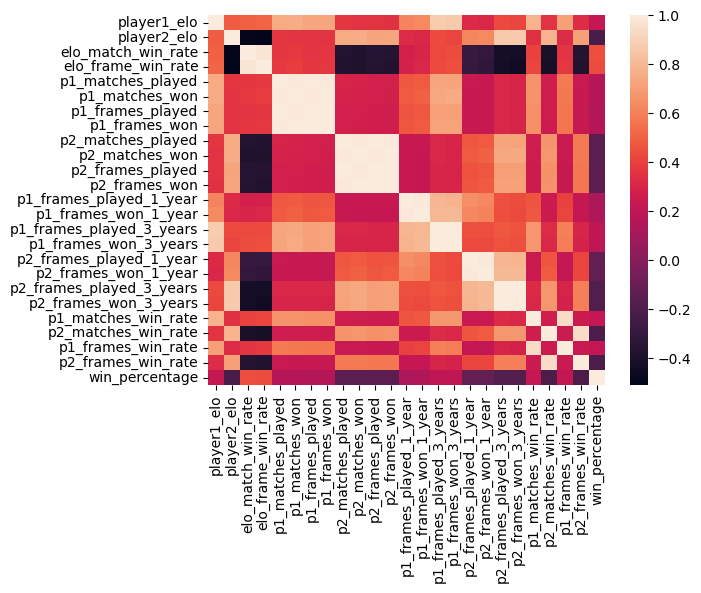

In [39]:
#We investigate the correlation among the following columns
columns = ['player1_elo', 'player2_elo',
       'elo_match_win_rate', 'elo_frame_win_rate', 'p1_matches_played',
       'p1_matches_won', 'p1_frames_played', 'p1_frames_won',
       'p2_matches_played', 'p2_matches_won', 'p2_frames_played',
       'p2_frames_won', 'p1_frames_played_1_year', 'p1_frames_won_1_year',
       'p1_frames_played_3_years', 'p1_frames_won_3_years',
       'p2_frames_played_1_year', 'p2_frames_won_1_year',
       'p2_frames_played_3_years', 'p2_frames_won_3_years', 
       'p1_matches_win_rate', 'p2_matches_win_rate',
       'p1_frames_win_rate', 'p2_frames_win_rate',
       'win_percentage']

corr = data[columns].corr()
sns.heatmap(corr)

In [40]:
#Print the features ranked by correlation with #Print the features ranked by correlation with win_percentage.
print(abs(corr["win_percentage"]).sort_values(ascending=False))

win_percentage              1.000000
elo_match_win_rate          0.444988
elo_frame_win_rate          0.437116
player1_elo                 0.224803
player2_elo                 0.218702
p1_matches_win_rate         0.216063
p1_frames_win_rate          0.213124
p2_frames_win_rate          0.205119
p2_matches_win_rate         0.204163
p1_frames_won_3_years       0.201114
p1_frames_played_3_years    0.198630
p2_frames_won_3_years       0.188409
p2_frames_played_3_years    0.186126
p1_matches_won              0.165106
p1_matches_played           0.160169
p1_frames_won               0.158917
p1_frames_played            0.155919
p2_matches_won              0.155563
p2_matches_played           0.150385
p2_frames_won               0.148245
p2_frames_played            0.145045
p1_frames_won_1_year        0.139522
p1_frames_played_1_year     0.132124
p2_frames_won_1_year        0.131668
p2_frames_played_1_year     0.125887
Name: win_percentage, dtype: float64


We see that within the features, one player's stats, e.g. matches played, matches won, etc, have high correlation with themselves.   

Also, players' elo rating have high correlation with their number of matches played in the recent three years.

Finally, the win rates predicted by our elo rating system have reached 0.44 correlation. This is promising. 

***

## 5. Principal Component Analysis

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [42]:
# Exclude the names and matches result from the analysis
X = data.drop(['player1', 'player2', 'match_result', 'win_percentage', 'score1', 'score2'], axis = 1)

In [43]:
X.describe()

,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,p1_frames_won,p2_matches_played,...,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,tournament_id,date,p1_frames_win_rate,p2_frames_win_rate,p1_matches_win_rate,p2_matches_win_rate
count,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,...,34521.000000,34521.000000,34521.000000,34521.000000,34521.000000,3.452100e+04,34521.000000,34521.000000,34521.000000,34521.000000
mean,7.785406,1275.929203,1275.259176,0.500616,0.500379,454.049072,269.010370,3230.077953,1756.654008,450.926566,...,114.395238,61.406274,550.464616,295.671591,3423.005272,9.954466e+17,0.497087,0.497150,0.504910,0.504331
std,3.518402,190.470845,190.788972,0.228921,0.114624,423.465148,276.984265,3177.920788,1809.616064,421.544434,...,124.373230,72.459847,430.718212,253.624279,1776.903193,2.426750e+18,0.084269,0.082684,0.141278,0.140781
min,1.000000,617.000000,625.000000,0.001333,0.144612,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,992.000000,-9.223372e+18,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1122.000000,1119.000000,0.329546,0.421895,79.000000,34.000000,464.000000,216.000000,79.000000,...,18.000000,8.000000,184.000000,82.000000,2186.000000,1.468109e+18,0.475649,0.474601,0.454545,0.453532
50%,7.000000,1297.000000,1297.000000,0.500000,0.500000,322.000000,167.000000,2115.000000,1083.000000,316.000000,...,71.000000,34.000000,478.000000,238.000000,2918.000000,1.555459e+18,0.517151,0.516673,0.533333,0.532407
75%,9.000000,1422.000000,1419.000000,0.670454,0.577495,759.000000,444.000000,5490.000000,2968.000000,757.000000,...,170.000000,88.000000,823.000000,446.000000,4923.000000,1.653264e+18,0.544571,0.543926,0.592930,0.591739
max,35.000000,1745.000000,1758.000000,0.998568,0.866458,1927.000000,1358.000000,14909.000000,8786.000000,1930.000000,...,753.000000,460.000000,1949.000000,1178.000000,6803.000000,1.748736e+18,0.818182,0.818182,1.000000,1.000000


In [44]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=25)
pca.fit(X)
print("Explained variance:", pca.explained_variance_)

Explained variance: [1.14715742e+01 6.23149337e+00 2.41122559e+00 1.24716384e+00
 1.15998447e+00 9.62845198e-01 9.19805569e-01 7.90801479e-01
 6.70387622e-01 3.82319947e-01 3.18404591e-01 1.34195918e-01
 1.16029001e-01 5.28399812e-02 4.96791292e-02 3.01128633e-02
 1.61354074e-02 1.14696967e-02 7.36339514e-03 6.02161267e-03
 4.63717561e-03 3.50056561e-03 1.20202906e-03 1.06904590e-03
 4.38978355e-04]


## 6. Explore the relation between distribution of the correct/incorrect prediction and different features

In [45]:
elo_prediction = data['player1_elo'] < data['player2_elo']
correct_prediction = data[data['match_result'] == elo_prediction]
inc_prediction = data[data['match_result'] != elo_prediction]

### Plot average

In [46]:
#This function plots histograms of correct and incorrect predictions against certain features. 
# Y-axis represents the average of player1's feature and player2's feature. 
def plot_both(feature):
    p1 = 'p1_' + feature
    p2 = 'p2_' + feature
    plt.hist([(correct_prediction[p1] + correct_prediction[p2])/2, (inc_prediction[p1] + inc_prediction[p2])/2]
             , bins=15, label = ['Correct', 'Incorrect'])
    plt.legend()
    plt.xlabel(feature)
    plt.title('Average ' + feature + ': correct vs incorrect')

    plt.show()

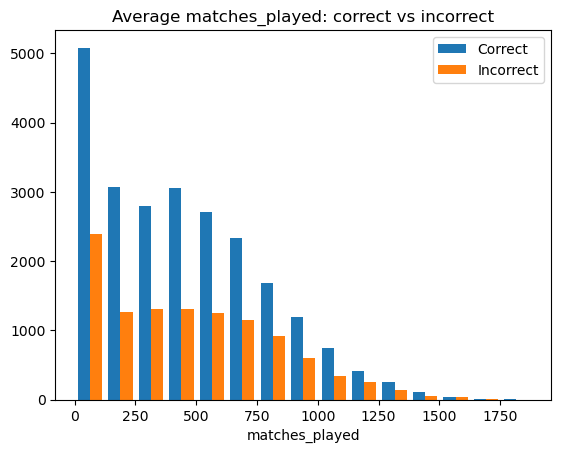

In [47]:
plot_both('matches_played')

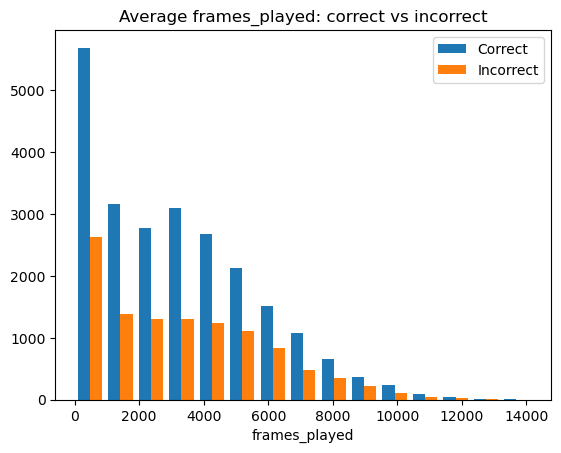

In [48]:
plot_both('frames_played')

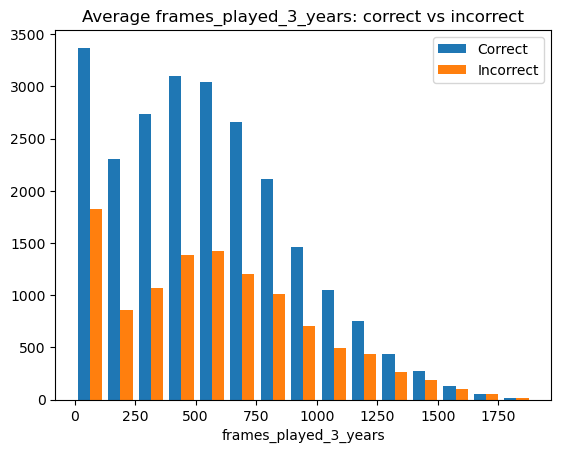

In [49]:
plot_both('frames_played_3_years')

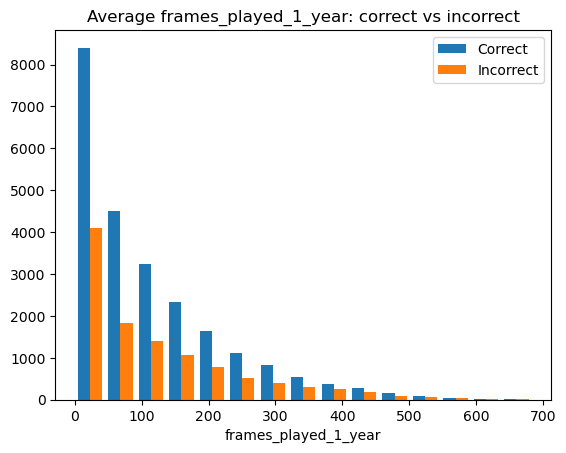

In [50]:
plot_both('frames_played_1_year')

### Plot difference

In [51]:
#This function plots histograms of correct and incorrect predictions against certain features. 
# Y-axis represents the difference of player1's feature and player2's feature. 
def plot_diff(feature):
    p1 = 'p1_' + feature
    p2 = 'p2_' + feature
    plt.hist([correct_prediction[p1] - correct_prediction[p2], inc_prediction[p1] - inc_prediction[p2]]
             , bins=15, label = ['Correct', 'Incorrect'])
    plt.legend()
    plt.xlabel(feature)
    plt.title('Difference of ' + feature + ': correct vs incorrect')

    plt.show()

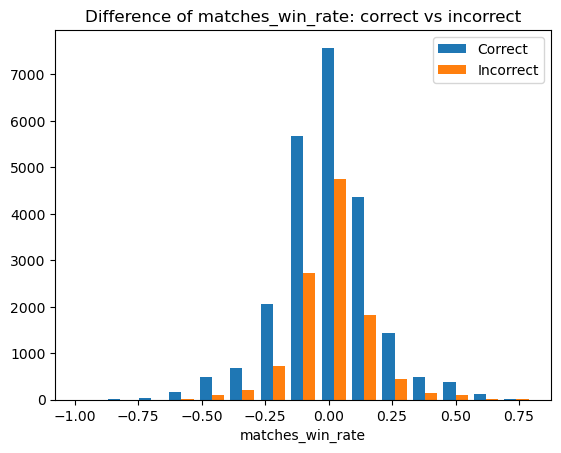

In [52]:
plot_diff('matches_win_rate')

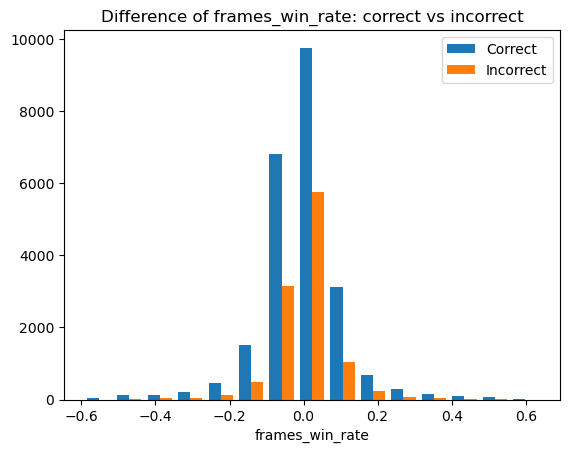

In [53]:
plot_diff('frames_win_rate')

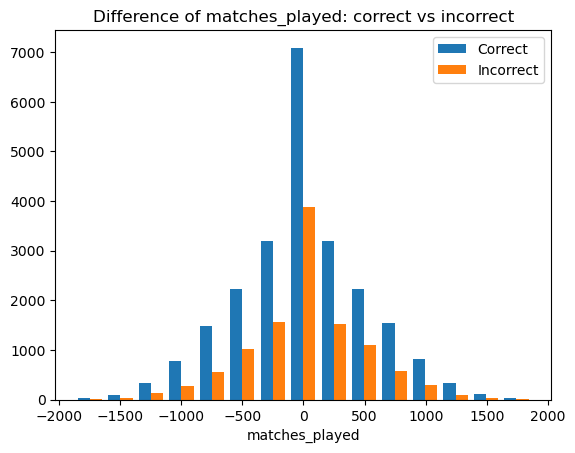

In [54]:
plot_diff('matches_played')

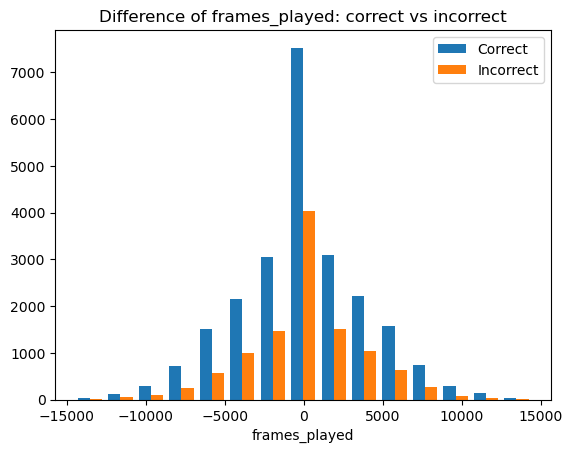

In [55]:
plot_diff('frames_played')

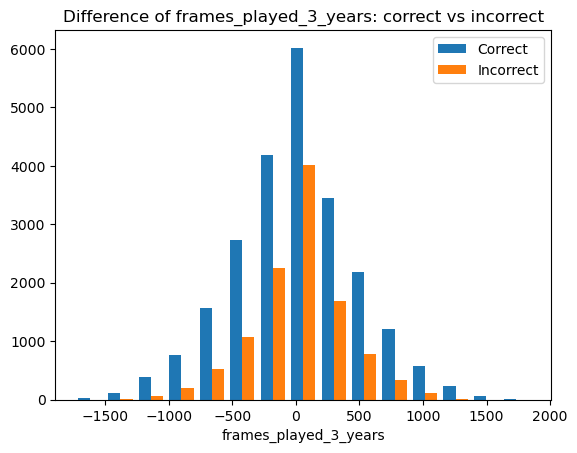

In [56]:
plot_diff('frames_played_3_years')

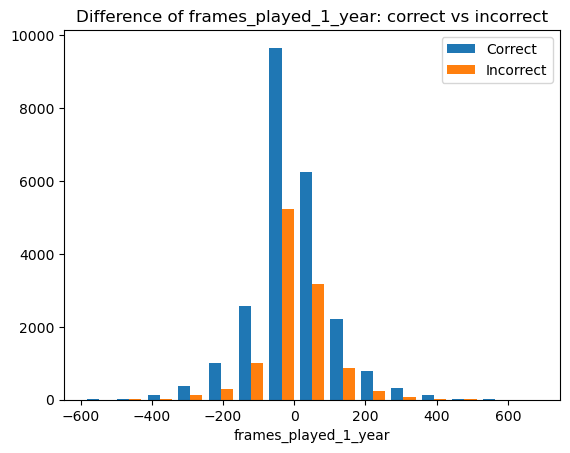

In [57]:
plot_diff('frames_played_1_year')

***

### Plot the distributions of difference and average of elo ratings

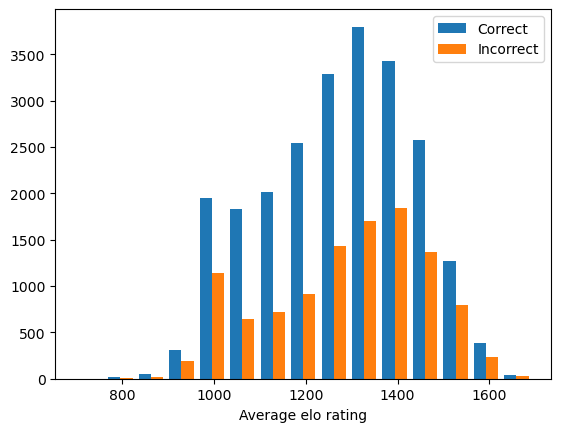

In [58]:
plt.hist([(correct_prediction['player1_elo']+correct_prediction['player2_elo'])/2, (inc_prediction['player1_elo']+inc_prediction['player2_elo'])/2],
          bins=15, label = ['Correct', 'Incorrect'])
plt.legend()
plt.xlabel('Average elo rating')
    
plt.show()

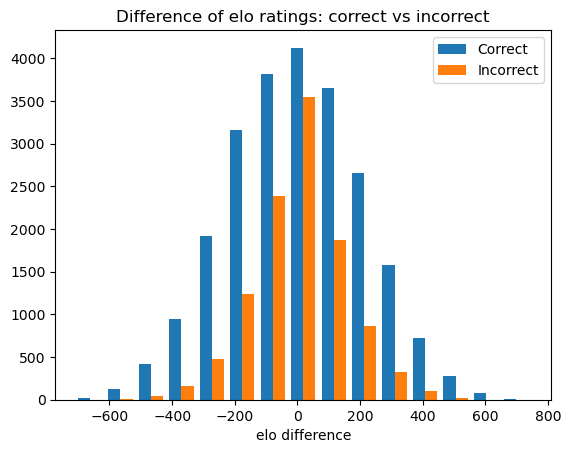

In [59]:
plt.hist([correct_prediction['player1_elo'] - correct_prediction['player2_elo'], inc_prediction['player1_elo'] - inc_prediction['player2_elo']]
             , bins=15, label = ['Correct', 'Incorrect'])
plt.legend()
plt.xlabel('elo difference')
plt.title('Difference of elo ratings: correct vs incorrect')

plt.show()